In [1]:
from Parts.imports import *
from Parts.data_loader import DatasetLoader, DatasetLoaderV2
from Parts.models import U_NET_VANILLA, U_NET_RESNET, U_NET_RESNET_ATTENTION, U_NET_PLUS_PLUS, TRANS_U_NET
from Parts.training_loop import TrainingLoop, TrainingLoopAdvanced, SaveState, EarlyStopping
from Parts.losses import DiceLoss, Mixed_Dice_Sigmoid

DEBUG = False

In [2]:
model = TRANS_U_NET()
# model_unet_resnet = U_NET_RESNET()
# model_unet_pp = U_NET_PLUS_PLUS()
# model_unet_trans = TRANS_U_NET()
optm = torch.optim.Adam(model.parameters())
loss = DiceLoss()

In [3]:
'''
model_states = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optm.state_dict(),
            'loss_history_epoch' : trainer.loss_history_epoch,
            'batch_loss' : trainer.loss_history,
            'val_loss' : trainer.loss_val
        }
'''

"\nmodel_states = {\n            'model_state_dict': model.state_dict(),\n            'optimizer_state_dict': optm.state_dict(),\n            'loss_history_epoch' : trainer.loss_history_epoch,\n            'batch_loss' : trainer.loss_history,\n            'val_loss' : trainer.loss_val\n        }\n"

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
device

'cpu'

In [5]:
PATH_TO_MODEL_WEIGHTS = r"model_weights/Trans_U_Net.torch"
df = torch.load(f=PATH_TO_MODEL_WEIGHTS, map_location=torch.device('cpu'))

In [6]:
model.load_state_dict(df['model_state_dict'])
model.eval()

TRANS_U_NET(
  (layers): ModuleDict(
    (encoder_0): U_NET_VANILLA_ENCODER(
      (downsample): Common_Module_BN(
        (conv): Sequential(
          (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
        )
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (decoder_0): U_NET_VANILLA_DECODER(
      (upsample): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
      (pipe): Common_Module_BN(
        (conv): Sequential(
          (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [7]:
data_test = r"C:\Users\itizs\Downloads\archive(1)\brisc2025\segmentation_task\test\images"
label_test = r"C:\Users\itizs\Downloads\archive(1)\brisc2025\segmentation_task\test\masks"

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.012549].


pred :: -11.020621299743652 8.965446472167969


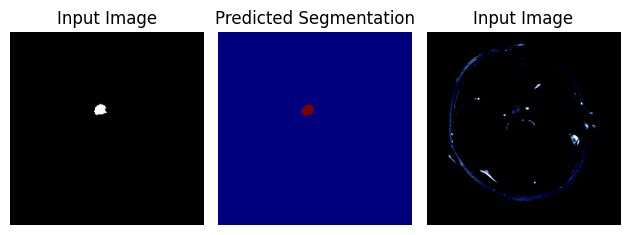

In [8]:
data_loader = DatasetLoaderV2(data_dir=data_test, label_dir=label_test, dim=(256, 256))
dataz =  DataLoader(data_loader, 1, 1)

for data, label in dataz:
    data = data.to(device)

    prediction = model(data)
    print(f"pred :: {prediction.min()} {prediction.max()}")
    prediction = torch.sigmoid(prediction)
    # prediction = (prediction > 0.5).float()
    final_mask = prediction.cpu().detach().numpy()
    final_mask = (final_mask > 0.5)
    fig, axes = plt.subplots(1, 3)

    axes[0].imshow(label.squeeze(), cmap='gray')
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    axes[1].imshow(final_mask.squeeze(), cmap='jet')
    axes[1].set_title("Predicted Segmentation")
    axes[1].axis('off')

    axes[2].imshow(data.detach().cpu().squeeze().numpy().transpose(1, 2, 0))
    axes[2].set_title("Input Image")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
    break

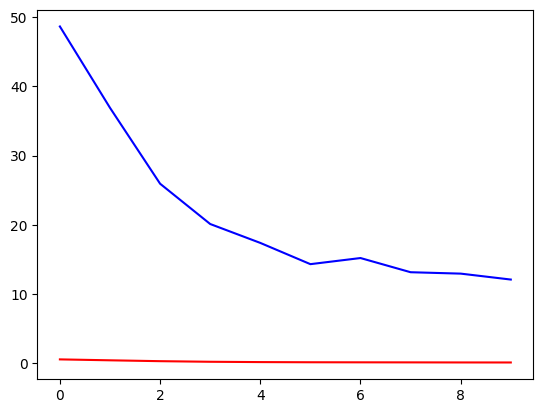

In [9]:
plt.plot(df['loss_history_epoch'], color = 'red')
# plt.plot(df['batch_loss'] , color = 'green')
df_sorry = [elem / 8 for elem in df['val_loss']]
plt.plot(df['val_loss'], color = 'blue')
plt.show()